In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import os, time, math, warnings
warnings.filterwarnings('ignore')
import polcal_lib_v2 as pln
import numpy as np
from matplotlib import pyplot as plt

In [5]:
def lm_test(cvm=True,istep=10.,niter=100,njacobian=True,autolambda=False,limits = None,accel=False):
    def test_func(x,a, **kwargs):
        x_length = len(x)
        pars_length = len(pars)
        jac = np.zeros((x_length,pars_length))
        y = a[0] + a[1]*x + a[2]*x**2
        jac[:,0] = 1
        jac[:,1] = x
        jac[:,2] = x**2
        return y,jac

    def test_func_res(a, **kwargs):
        ch = (y - (a[0] + a[1]*x + a[2]*x**2))**2
        return ch
    def test_func_jac(a, **kwargs):
        # return pln.numerical_der(x,pars,test_func_res, **kwargs)

        x_length = len(x)
        pars_length = len(a)
        jac = np.zeros((x_length,pars_length))
        jac[:,0] = - 1 * 2.* (y - (a[0] + a[1]*x + a[2]*x**2))
        jac[:,1] = - x * 2.* (y - (a[0] + a[1]*x + a[2]*x**2))
        jac[:,2] = - x**2 * 2.* (y - (a[0] + a[1]*x + a[2]*x**2))
        return jac

    x = np.arange(50)
    pars = [.75,1.70,2.45]
    y,jac = test_func(x,pars)
    y = y + y*np.random.uniform(-1,1,50)*1e-2
    pars = [.70,1.10,0.45]
    #new_pars,yfit = lm(x, y, pars, test_func)

    pars,yfit , _  ,_ = pln.lm(x, y, pars,test_func,njacobian=False,niter=niter,cvm=False,istep=istep,autolambda=autolambda,limits=limits,accel=accel)
    plt.plot(x,y,'o')
    plt.plot(x,yfit)
    print([.75,1.70,2.45],pars)
    plt.show()
    plt.plot(x,y-yfit,'.-')
    plt.show()

    lm = pln.LM(test_func_res,test_func_jac)
    p1, err, message = lm.leastsq([.70,1.10,0.45],x=x,y=y,iprint=1)
    
    yfit = (p1[0] + p1[1]*x + p1[2]*x**2)
    plt.plot(x,y,'o')
    plt.plot(x,yfit)
    print([.75,1.70,2.45],p1)
    plt.show()
    plt.plot(x,y-yfit,'.-')
    plt.show()


weights is float
None
Fix is None
Iter:   0 Lambda:   1.0000e+01 chi2: 5.13e+06 better
Iter:   1 Lambda:   1.0000e+00 chi2: 3.33e+06 better
Iter:   2 Lambda:   1.0000e-01 chi2: 4.94e+05 better
Iter:   3 Lambda:   1.0000e-02 chi2: 3.36e+04 better
Iter:   4 Lambda:   1.0000e-03 chi2: 3.59e+03 better
Iter:   5 Lambda:   1.0000e-04 chi2: 2.09e+02 better
Iter:   6 Lambda:   1.0000e-05 chi2: 1.82e+02 better
Iter:   7 Lambda:   1.0000e-06 chi2: 1.82e+02 better
STOP because (ochi2 - chi2)/chi2)*100 < chi2_stop
[0.75, 1.7, 2.45] [2.85665248 1.45840932 2.45466677]


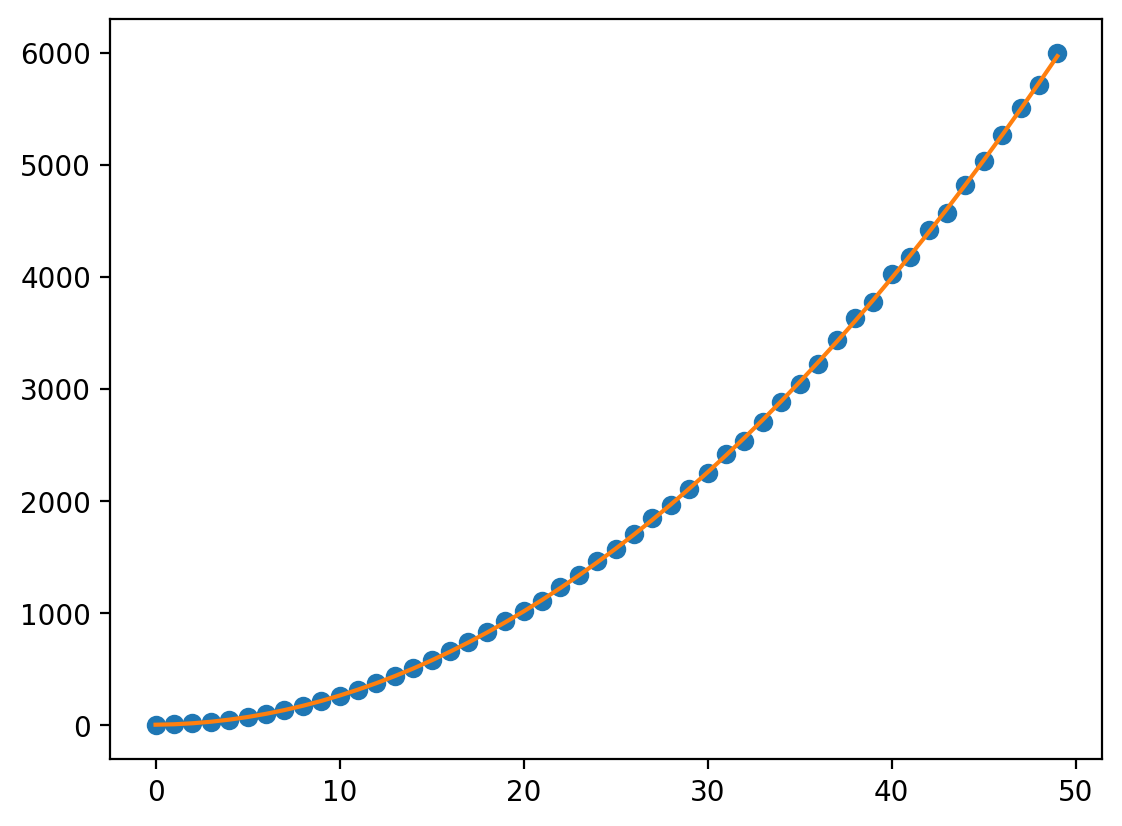

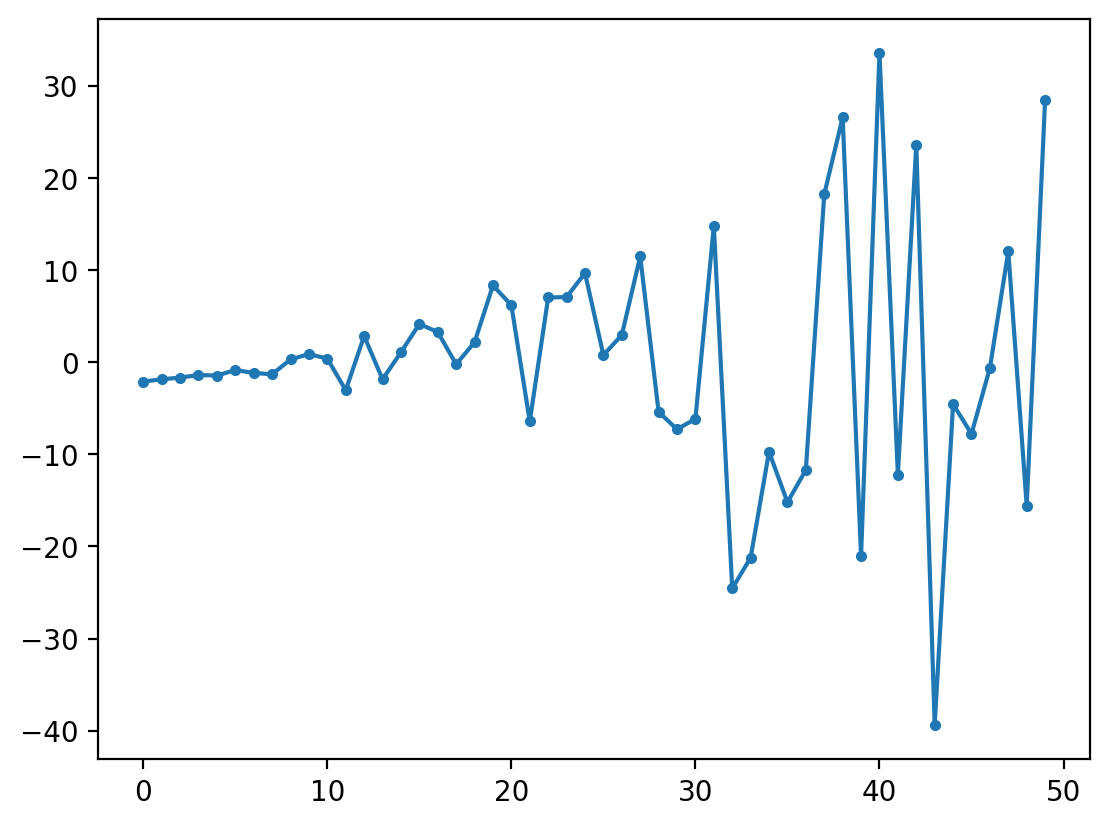

Itn 0: nlnprob = 1631099037556611.5
	success = True, lnprob = 32274941973818.54,                           lamb = 1.0
Itn 1: nlnprob = 32274941973818.54
	success = True, lnprob = 640976847426.9019,                           lamb = 0.1
Itn 2: nlnprob = 640976847426.9019
	success = True, lnprob = 13060691961.780151,                           lamb = 0.01
Itn 3: nlnprob = 13060691961.780151
	success = True, lnprob = 309753761.46643555,                           lamb = 0.001
Itn 4: nlnprob = 309753761.46643555
	success = True, lnprob = 11154213.91569788,                           lamb = 0.0001
Itn 5: nlnprob = 11154213.91569788
	success = True, lnprob = 3745042.1103758933,                           lamb = 1e-05
Itn 6: nlnprob = 3745042.1103758933
	success = False, lnprob = 4167101.5004110355,                           lamb = 5e-05
	success = False, lnprob = 4167115.472032311,                           lamb = 0.00025
	success = False, lnprob = 4167101.699467423,                           lam

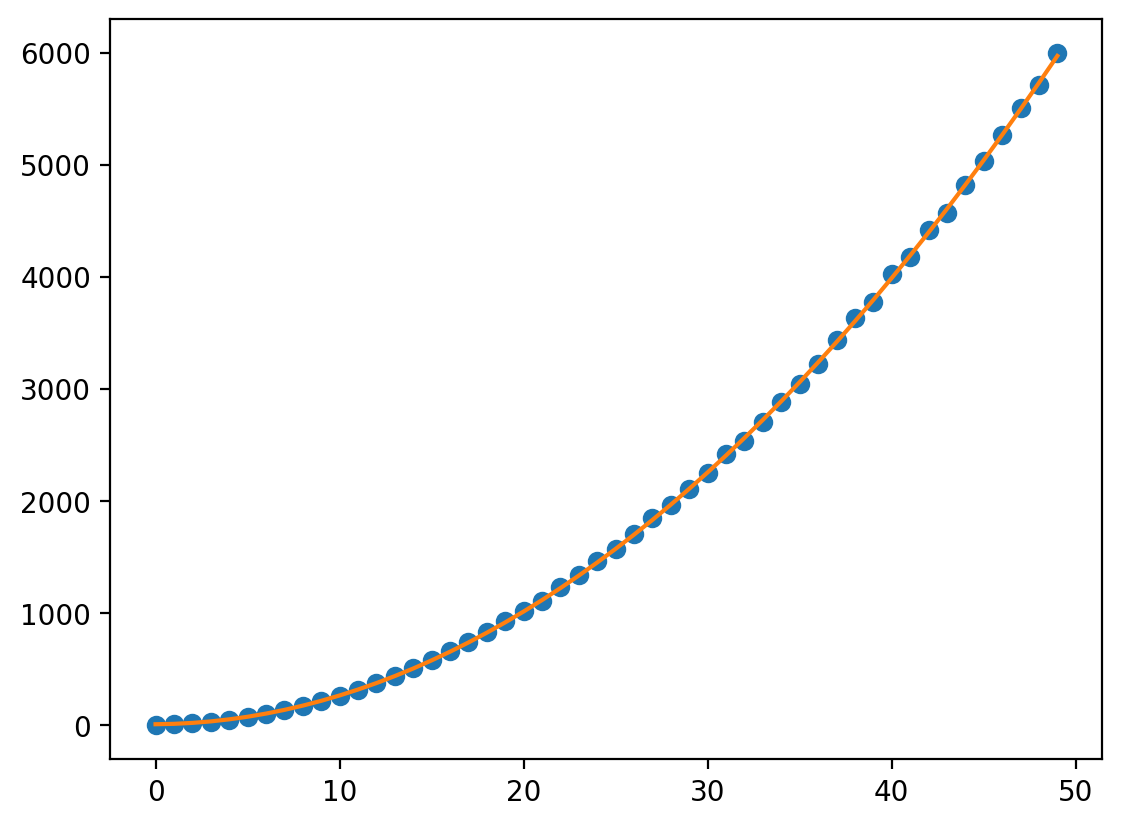

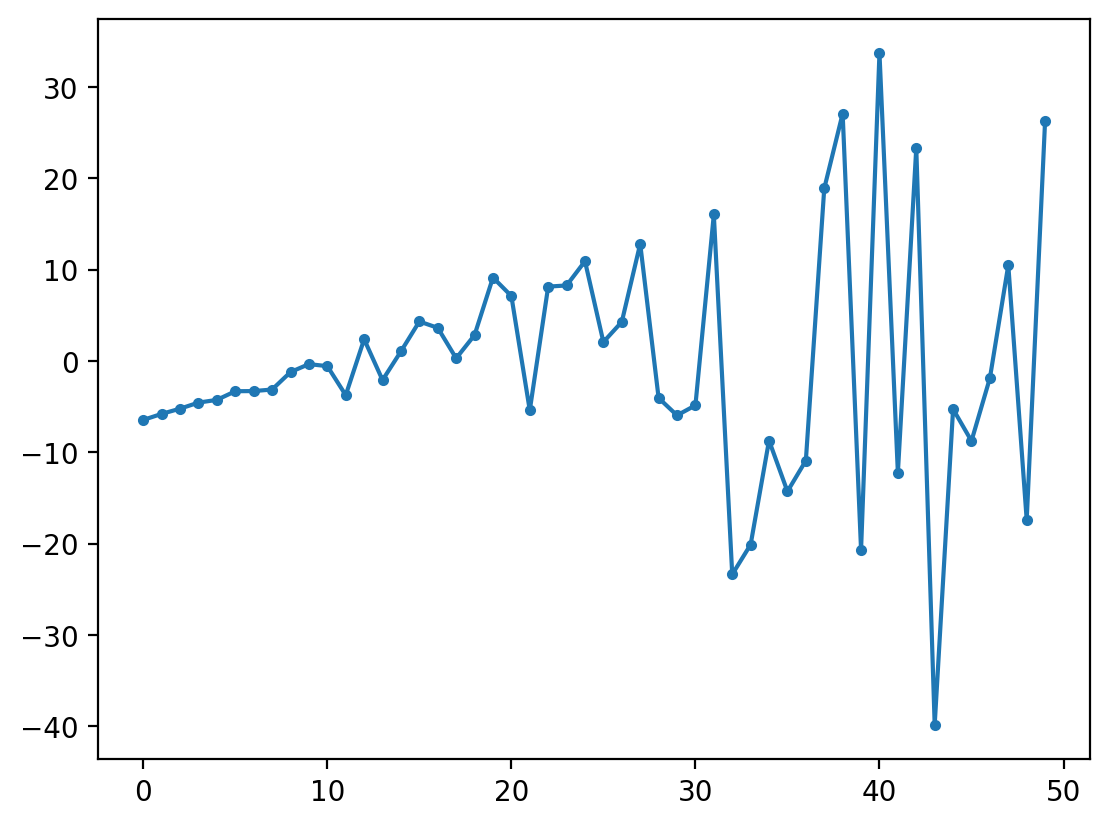

In [3]:
lm_test(accel=True)